In [1]:
from google.colab import files
uploaded = files.upload()




Saving E-commerce Customer Behavior - Sheet1.csv to E-commerce Customer Behavior - Sheet1.csv


In [2]:
import pandas as pd

df = pd.read_csv("E-commerce Customer Behavior - Sheet1.csv")

df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [3]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [4]:
total_customers = df['Customer ID'].nunique()

purchased_items = df[df['Items Purchased'] > 0]['Customer ID'].nunique()

spending_customers = df[df['Total Spend'] > 0]['Customer ID'].nunique()

discount_users = df[df['Discount Applied'] == True]['Customer ID'].nunique()

import pandas as pd

funnel = pd.DataFrame({
    'Stage': ['Total Customers', 'Purchased Items', 'Spent Money', 'Used Discount'],
    'Users': [total_customers, purchased_items, spending_customers, discount_users]
})

funnel

,Stage,Users
0,Total Customers,350
1,Purchased Items,350
2,Spent Money,350
3,Used Discount,175


In [5]:
funnel['Conversion Rate (%)'] = (funnel['Users'] / funnel['Users'].shift(1)) * 100
funnel.loc[0, 'Conversion Rate (%)'] = 100

funnel

,Stage,Users,Conversion Rate (%)
0,Total Customers,350,100.0
1,Purchased Items,350,100.0
2,Spent Money,350,100.0
3,Used Discount,175,50.0


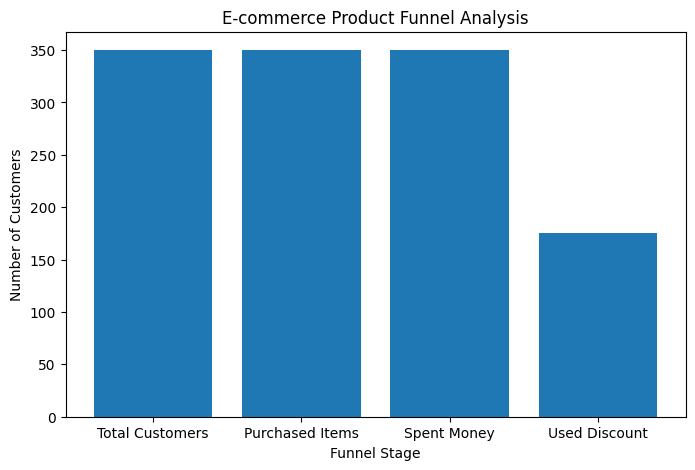

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(funnel['Stage'], funnel['Users'])

plt.title("E-commerce Product Funnel Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Customers")

plt.show()

Key Insights

• Most customers in the dataset made purchases and contributed to revenue.
• A smaller portion of customers used discounts during their purchases.
• Discount usage could be a strategy to improve conversions and customer engagement.

Product Funnel Analysis using Python

In [7]:
total_customers = df['Customer ID'].nunique()

repeat_customers = df[df['Items Purchased'] >= 10]['Customer ID'].nunique()

high_value_customers = df[df['Total Spend'] >= 1000]['Customer ID'].nunique()

discount_users = df[df['Discount Applied'] == True]['Customer ID'].nunique()

better_funnel = pd.DataFrame({
    'Stage': ['Total Customers', 'Repeat Buyers (10+ Items)', 'High-Value Customers ($1000+)', 'Used Discount'],
    'Users': [total_customers, repeat_customers, high_value_customers, discount_users]
})

better_funnel

,Stage,Users
0,Total Customers,350
1,Repeat Buyers (10+ Items),258
2,High-Value Customers ($1000+),117
3,Used Discount,175


In [8]:
better_funnel['Conversion Rate (%)'] = (better_funnel['Users'] / better_funnel['Users'].shift(1)) * 100
better_funnel.loc[0, 'Conversion Rate (%)'] = 100
better_funnel['Conversion Rate (%)'] = better_funnel['Conversion Rate (%)'].round(2)

better_funnel['Drop-off'] = better_funnel['Users'].shift(1) - better_funnel['Users']
better_funnel.loc[0, 'Drop-off'] = 0

better_funnel

,Stage,Users,Conversion Rate (%),Drop-off
0,Total Customers,350,100.00,0.0
1,Repeat Buyers (10+ Items),258,73.71,92.0
2,High-Value Customers ($1000+),117,45.35,141.0
3,Used Discount,175,149.57,-58.0


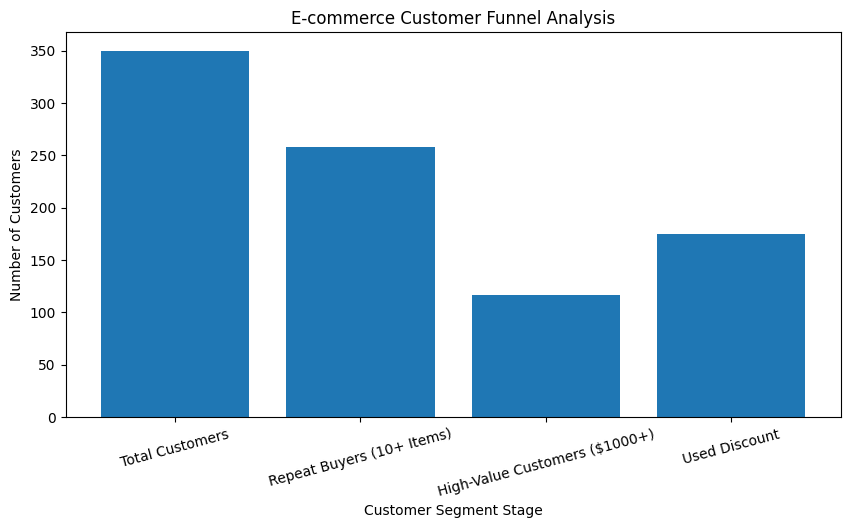

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(better_funnel['Stage'], better_funnel['Users'])
plt.title('E-commerce Customer Funnel Analysis')
plt.xlabel('Customer Segment Stage')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

Key Insights

All customers in the dataset made purchases, but a smaller group became repeat buyers with 10 or more items purchased.

The customer count drops further for high-value customers who spent $1000 or more.

Only part of the customer base used discounts, which suggests discount campaigns are not reaching everyone.

Recommendations

Target medium-purchase customers with personalized offers to increase repeat buying.

Create loyalty campaigns for customers close to the high-value segment.

Test discount strategies for less active customers to improve engagement and retention.

# Customer Funnel Analysis for E-commerce Behavior using Python

## Objective
The goal of this project is to analyze customer behavior in an e-commerce dataset and understand how customers move through different engagement stages such as purchasing items, becoming repeat buyers, and becoming high-value customers.

## Tools Used
- Python
- Pandas
- Matplotlib
- Google Colab

## Dataset
E-commerce Customer Behavior Dataset